# 02 · Synthetic DTI calibration

How unrecorded Pay-in-4 loan stacking inflates borrower debt burden across income brackets, and what that implies for the default multiplier **M** handed to the Track 3 waterfall.

$$DTI_{true} = DTI_{reported} + \frac{(AOV/4)\cdot 2 \cdot N_{active}}{\text{gross monthly income}}$$

Inputs: `src/models/synthetic_dti.py`, `data/processed/bnpl_lender_kpis.csv` (Affirm 10-K/10-Q), `data/processed/anchor_deal_*.csv` (EART 2026-4).
Macro features are the **mock fixture** until Track 1 merges.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src" / "models"))
from synthetic_dti import INCOME_BRACKETS, TRUE_BETAS, SyntheticDTIModel, load_kpis, load_macro

# Reference palette (light mode): categorical slots 1-2, blue sequential ramp, recessive ink
SERIES = ["#2a78d6", "#eb6834"]
BLUE_RAMP = ["#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#104281"]
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False,
})
QM_DTI_CAP = 0.43  # CFPB Qualified Mortgage benchmark, used as a stress reference line

model = SyntheticDTIModel(aov=320.0, active_loans=3)
kpis = load_kpis()
macro, macro_source = load_macro()
print(f"macro source: {macro_source}; Affirm quarters: {len(kpis)}")

macro source: mock; Affirm quarters: 23


## 1 · Benchmark stack: three Pay-in-4 loans at a $320 AOV

Each bracket keeps its bureau-visible DTI; the orange segment is the Pay-in-4 outflow that never reaches the bureau. The same $480/month is a much larger share of a $35k income than of a $110k one.

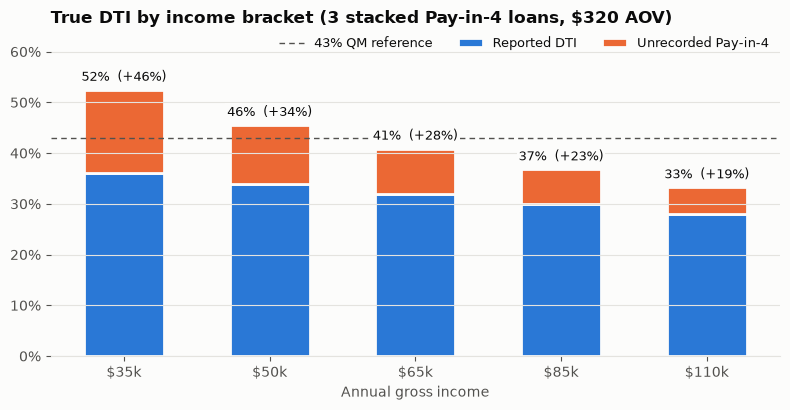

,income,reported_dti,dti_bnpl,true_dti,surge,bnpl_pmt
0,"$35,000",36.0%,16.5%,52.5%,+45.7%,$480
1,"$50,000",34.0%,11.5%,45.5%,+33.9%,$480
2,"$65,000",32.0%,8.9%,40.9%,+27.7%,$480
3,"$85,000",30.0%,6.8%,36.8%,+22.6%,$480
4,"$110,000",28.0%,5.2%,33.2%,+18.7%,$480


In [2]:
brackets = pd.DataFrame(list(INCOME_BRACKETS.items()), columns=["income", "reported_dti"])
s = model.calculate_synthetic_dti(brackets["reported_dti"], brackets["income"])
brackets = brackets.assign(dti_bnpl=s["dti_bnpl"], true_dti=s["true_dti"], surge=s["dti_surge_pct"],
                           bnpl_pmt=s["monthly_bnpl_pmt"])

fig, ax = plt.subplots(figsize=(8, 4.2))
labels = [f"${i/1000:.0f}k" for i in brackets["income"]]
x = np.arange(len(labels))
ax.bar(x, brackets["reported_dti"], width=0.55, color=SERIES[0], label="Reported DTI", edgecolor=SURFACE, linewidth=2)
ax.bar(x, brackets["dti_bnpl"], width=0.55, bottom=brackets["reported_dti"], color=SERIES[1],
       label="Unrecorded Pay-in-4", edgecolor=SURFACE, linewidth=2)
for xi, t, su in zip(x, brackets["true_dti"], brackets["surge"]):
    ax.text(xi, t + 0.012, f"{t:.0%}  (+{su:.0%})", ha="center", va="bottom", fontsize=9, color=INK, zorder=4,
            bbox=dict(boxstyle="square,pad=0.15", fc=SURFACE, ec="none"))
ax.axhline(QM_DTI_CAP, color=INK_2, lw=1, ls=(0, (4, 3)), zorder=1, label="43% QM reference")
ax.set_xticks(x, labels); ax.set_xlabel("Annual gross income")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylim(0, 0.64); ax.grid(axis="x", visible=False)
ax.set_title("True DTI by income bracket (3 stacked Pay-in-4 loans, $320 AOV)")
ax.legend(loc="upper right", ncol=3, bbox_to_anchor=(1, 1.02), fontsize=9)
plt.tight_layout(); plt.show()

brackets.style.format({"income": "${:,.0f}", "reported_dti": "{:.1%}", "dti_bnpl": "{:.1%}", "true_dti": "{:.1%}",
                       "surge": "+{:.1%}", "bnpl_pmt": "${:,.0f}"})

## 2 · How far does stacking go before a borrower crosses 43%?

True DTI across income (columns) and number of concurrently open Pay-in-4 loans (rows). Cells outlined in dark ink are above the 43% reference.

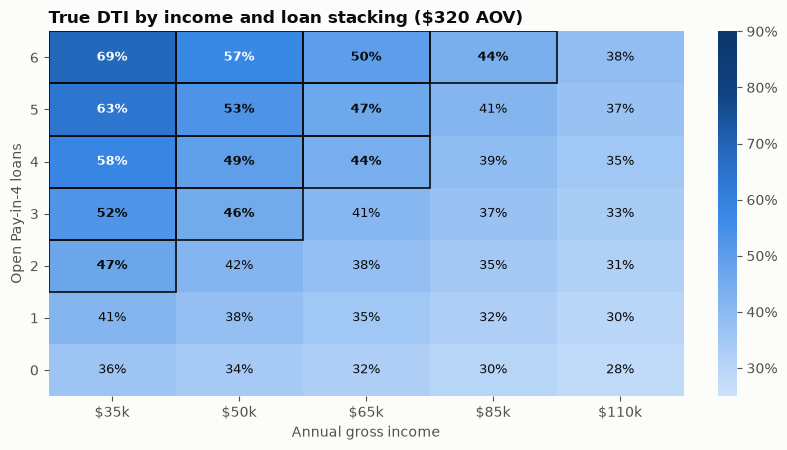

,loans needed to breach 43%
$35k,2
$50k,3
$65k,4
$85k,6
$110k,never (<= 6)


In [3]:
loans = np.arange(0, 7)
grid = np.array([[model.calculate_synthetic_dti(rd, inc, active_loans=n)["true_dti"] for inc, rd in INCOME_BRACKETS.items()]
                 for n in loans])

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("blue_seq", ["#cde2fb"] + BLUE_RAMP + ["#0d366b"])
fig, ax = plt.subplots(figsize=(8, 4.6))
im = ax.imshow(grid, cmap=cmap, aspect="auto", origin="lower", vmin=0.25, vmax=0.9)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=9,
                color="#ffffff" if v > 0.55 else INK, fontweight="bold" if v > QM_DTI_CAP else "normal")
        if v > QM_DTI_CAP:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec=INK, lw=1.2))
ax.set_xticks(range(len(INCOME_BRACKETS)), [f"${i/1000:.0f}k" for i in INCOME_BRACKETS])
ax.set_yticks(loans, loans); ax.set_xlabel("Annual gross income"); ax.set_ylabel("Open Pay-in-4 loans")
ax.grid(False); ax.spines["bottom"].set_visible(False)
ax.set_title("True DTI by income and loan stacking ($320 AOV)")
cb = fig.colorbar(im, ax=ax, format=mtick.PercentFormatter(1.0), fraction=0.04); cb.outline.set_visible(False)
plt.tight_layout(); plt.show()

first_breach = {f"${inc/1000:.0f}k": str(loans[np.argmax(grid[:, j] > QM_DTI_CAP)]) if (grid[:, j] > QM_DTI_CAP).any() else "never (<= 6)"
                for j, inc in enumerate(INCOME_BRACKETS)}
pd.Series(first_breach, name="loans needed to breach 43%").to_frame()

## 3 · Stacking over time, driven by Affirm's filed KPIs

Starts Sep-2021, the first quarter with a trailing-12-month GMV. AOV (GMV per transaction) fell from ~$477 to ~$259 while transactions per active consumer rose from 2.3 to 7.0. `N_active` scales with transactions per consumer (3 loans at the latest 7.0), so the monthly BNPL outflow tracks **AOV × frequency** — and it has risen.

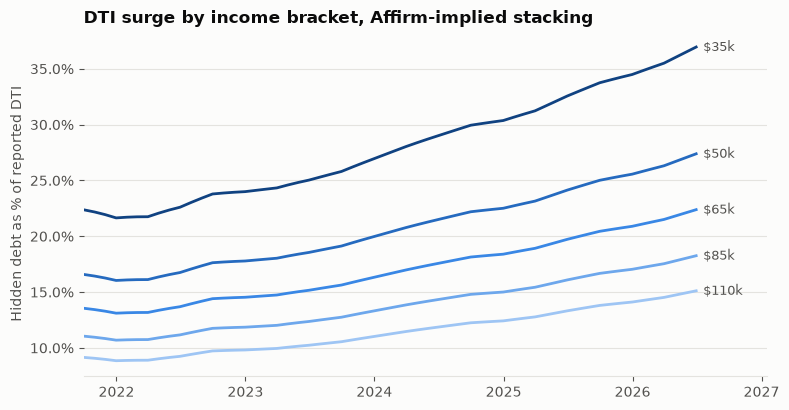

,period_end,aov_derived_usd,transactions_per_active_consumer,dpd_30plus_pct
15,2024-09-30,$288,5.1,2.72%
16,2024-12-31,$281,5.3,2.72%
17,2025-03-31,$273,5.6,2.65%
18,2025-06-30,$275,5.8,2.46%
19,2025-09-30,$271,6.1,2.88%
20,2025-12-31,$264,6.4,2.63%
21,2026-03-31,$260,6.7,2.79%
22,2026-06-30,$259,7.0,2.51%


In [4]:
panel = model.build_features(macro, kpis, brackets=INCOME_BRACKETS)
fig, ax = plt.subplots(figsize=(8, 4.2))
for color, (inc, g) in zip(BLUE_RAMP[::-1], panel.groupby("income")):
    ax.plot(g["date"], g["dti_surge"], color=color, lw=2)
    ax.text(g["date"].iloc[-1] + pd.Timedelta(days=20), g["dti_surge"].iloc[-1], f"${inc/1000:.0f}k",
            va="center", fontsize=9, color=INK_2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("Hidden debt as % of reported DTI"); ax.grid(axis="x", visible=False)
ax.set_title("DTI surge by income bracket, Affirm-implied stacking")
ax.set_xlim(panel["date"].min(), panel["date"].max() + pd.Timedelta(days=200))
plt.tight_layout(); plt.show()

kpis[["period_end", "aov_derived_usd", "transactions_per_active_consumer", "dpd_30plus_pct"]].tail(8).style.format(
    {"aov_derived_usd": "${:,.0f}", "transactions_per_active_consumer": "{:.1f}", "dpd_30plus_pct": "{:.2%}"})

## 4 · Estimator validation (synthetic target with planted betas)

Before fitting anything real, the OLS is run on a target generated from known coefficients over the income × month panel. It should recover them. (A single benchmark borrower cannot do this: its DTI surge is a pure time trend, collinear with the savings series.)

In [5]:
val, _ = model.calibrate_default_multiplier(macro, kpis, target="synthetic")
pd.DataFrame({"true": TRUE_BETAS, "estimated": val.params, "cluster SE": val.bse,
              "within 2 SE": (val.params - pd.Series(TRUE_BETAS)).abs() < 2 * val.bse}).round(4)

,true,estimated,cluster SE,within 2 SE
const,1.00,0.9996,0.0036,True
dti_surge,0.40,0.3980,0.0178,True
savings_contraction,0.08,0.0799,0.0005,True
complaint_velocity,0.15,0.1554,0.0117,True


## 5 · Empirical multiplier: Affirm 30+ DPD relative to FY2021

M = Affirm 30+ DPD rate ÷ its first-four-quarter average. **Caveats before this goes into the waterfall:**
- macro regressors are still mock, so β₂/β₃ are placeholders;
- the DTI-surge coefficient is not identified here: it is insignificant (p ≈ 0.8) and its sign flips (≈ −20 → +2) depending on whether the FY2021 stimulus-era quarters are in the sample. Affirm's delinquencies fell after FY2022 while usage rose because underwriting tightened, so a lender's own book is not a clean read of borrower-level stress;
- 20 quarterly observations and Durbin-Watson ≈ 0.95, so treat standard errors as optimistic even with HAC.

                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.6304      0.825      1.976      0.048       0.014       3.247
dti_surge               2.0642      7.068      0.292      0.770     -11.788      15.916
savings_contraction    -0.0670      0.082     -0.821      0.412      -0.227       0.093
complaint_velocity      0.1100      0.523      0.210      0.833      -0.915       1.135


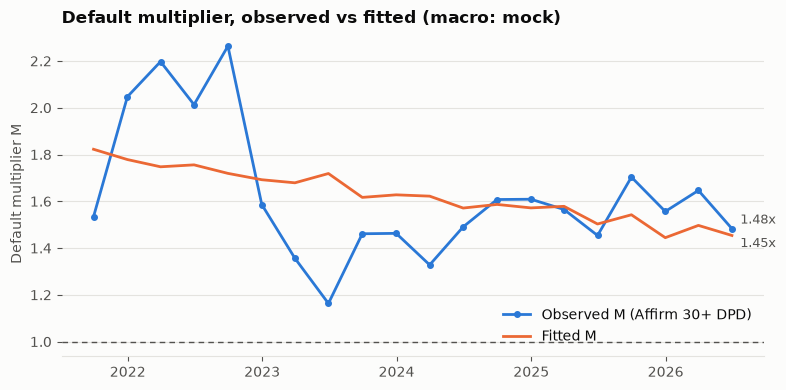

In [6]:
emp, reg = model.calibrate_default_multiplier(macro, kpis, target="affirm")
print(emp.summary().tables[1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(reg["date"], reg["empirical_m"], color=SERIES[0], lw=2, marker="o", ms=4, label="Observed M (Affirm 30+ DPD)")
ax.plot(reg["date"], reg["predicted_m"], color=SERIES[1], lw=2, label="Fitted M")
# End labels, nudged apart so they never collide
ends = sorted(((reg[col].iloc[-1], col) for col in ("empirical_m", "predicted_m")))
for (v, col), dy in zip(ends, (-6, 6)):
    ax.annotate(f"{v:.2f}x", (reg["date"].iloc[-1], v), xytext=(6, dy), textcoords="offset points",
                va="center", fontsize=9, color=INK_2)
ax.axhline(1, color=INK_2, lw=1, ls=(0, (4, 3)))
ax.set_ylabel("Default multiplier M"); ax.grid(axis="x", visible=False)
ax.set_title(f"Default multiplier, observed vs fitted (macro: {macro_source})")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 6 · Anchor deal context

What the multiplier is ultimately applied to: EART 2026-4 hard credit enhancement by class.

In [7]:
deal = pd.read_csv(ROOT / "data" / "processed" / "anchor_deal_structure.csv")
pool = pd.read_csv(ROOT / "data" / "processed" / "anchor_deal_collateral.csv", index_col="field")["value"]
print(f"Pool ${float(pool['original_collateral_balance_usd'])/1e6:,.1f}m | WAC {pool['gross_wac_pct']}% | "
      f"WA FICO {pool['wa_fico']} | WA PTI {pool['wa_payment_to_income_pct']}% | OC target {pool['oc_target_pct_current_pool']}%")
deal[["note_class", "initial_principal_usd", "coupon_pct", "rating_moodys", "rating_sp", "initial_hard_ce_pct",
      "initial_hard_ce_incl_reserve_pct"]].style.format(
    {"initial_principal_usd": "${:,.0f}", "coupon_pct": "{:.2f}%", "initial_hard_ce_pct": "{:.1%}",
     "initial_hard_ce_incl_reserve_pct": "{:.1%}"}, na_rep="—")

Pool $1,108.0m | WAC 20.49% | WA FICO 566 | WA PTI 10.39% | OC target 11.65%


,note_class,initial_principal_usd,coupon_pct,rating_moodys,rating_sp,initial_hard_ce_pct,initial_hard_ce_incl_reserve_pct
0,A-1,"$119,000,000",4.02%,P-1 (sf),A-1+ (sf),52.1%,53.1%
1,A-2,"$164,550,000",4.37%,Aaa (sf),AAA (sf),52.1%,53.1%
2,A-3,"$246,630,000",4.56%,Aaa (sf),AAA (sf),52.1%,53.1%
3,B,"$115,230,000",4.87%,Aaa (sf),AA (sf),41.8%,42.8%
4,C,"$118,550,000",5.16%,Aa3 (sf),A (sf),31.1%,32.1%
5,D,"$159,560,000",5.64%,Baa3 (sf),BBB (sf),16.7%,17.7%
6,E,"$107,470,000",7.58%,NR (144A),NR (144A),7.0%,8.0%
7,N,"$29,916,000",6.68%,NR (144A),NR (144A),—,—
